In [6]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from scipy.stats import median_abs_deviation as mad
import pandas as pd
plt.style.use('thesis')

In [7]:
wav = np.load('/home/vmehta/honours-project/code/data/wavelengths.npy')

In [9]:
bands1 = []
bands2 = []
bands5 = []
for i in range(10):
    residual = res10[:, i]
    median_residual = np.median(residual)
    lower1 = median_residual - 0.01
    upper1 = median_residual + 0.01
    lower2 = median_residual - 0.02
    upper2 = median_residual + 0.02
    lower5 = median_residual - 0.05
    upper5 = median_residual + 0.05
    bands1.append((lower1, upper1))
    bands2.append((lower2, upper2))
    bands5.append((lower5, upper5))

In [10]:
band_specs = [
    (bands5, '#cfe8f3', '5% band', 3),
    (bands2, '#73bfe2', '2% band', 4),
]

In [12]:
def moving_average(x, w):
        """Returns the moving average of the input array."""
        return np.convolve(x, np.ones(w), 'same') / w

def normalize(v):
    s_flat = v / moving_average(v, 100)
    return s_flat * moving_average(np.ones_like(s_flat), 100)  # dealing with edges

## Testing 3 6 and 10 labels with updated model
Log-fluxes vs linear fluxes

In [120]:
lin_pred_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260416_155956/binconf2/newpriorthing/snr1000_all_pred.npy')
lin_true_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260416_155956/binconf2/newpriorthing/snr1000_all_true.npy')
# log_pred_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260331_170324/finalmodeltest/log-flux/snr1000_all_pred.npy')
# log_true_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260331_170324/finalmodeltest/log-flux/snr1000_all_true.npy')

res_lin_6 = lin_pred_6 - lin_true_6
# = log_pred_6 - log_true_6
sixspec = np.load('/home/vmehta/honours-project/code/data/sfh_sixbinsconf2_spectra.npy')
six_norm_vals = [normalize(v) for v in sixspec]

In [121]:
mad5lower = np.median(res_lin_6) - 5*mad(res_lin_6)
mad5upper = np.median(res_lin_6) + 5*mad(res_lin_6)
mad5lower, mad5upper

(array([-0.006328  , -0.01924639, -0.02477632, -0.00970326, -0.01974928,
        -0.00917914]),
 array([0.006328  , 0.01924639, 0.02477632, 0.00970326, 0.01974928,
        0.00917914]))

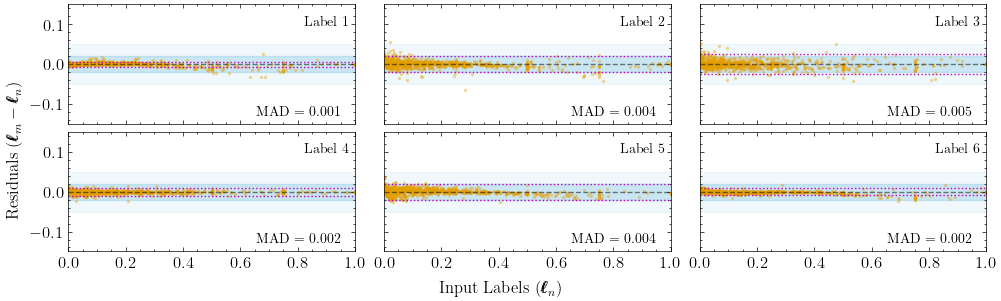

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(10,3), sharex=True, sharey=True, constrained_layout=True)
for i in range(3):
    ax[0, i].plot(lin_true_6[:,i], res_lin_6[:,i], '.', markersize=3, alpha=0.3)
    ax[1, i].plot(lin_true_6[:,3+i], res_lin_6[:,3+i], '.', markersize=3, alpha=0.3)
    ax[0, i].plot([0,1], [0,0], 'k--', alpha=0.5)
    ax[1, i].plot([0,1], [0,0], 'k--', alpha=0.5)
    ax[0, i].hlines([mad5lower[i]], [0], [1], 'm', linestyles='dotted')
    ax[1, i].hlines([mad5lower[i+3]], [0], [1], 'm', linestyles='dotted')
    ax[0, i].hlines([mad5upper[i]], [0], [1], 'm', linestyles='dotted')
    ax[1, i].hlines([mad5upper[i+3]], [0], [1], 'm', linestyles='dotted')
    ax[0, i].text(0.98, 0.9, f'Label {i+1}', transform=ax[0, i].transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
    ax[1, i].text(0.98, 0.9, f'Label {i+4}', transform=ax[1, i].transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
    ax[0, i].text(0.95, 0.05, f'MAD = {mad(res_lin_6[:,i]):.3f}', transform=ax[0, i].transAxes, fontsize=10, va='bottom', ha='right')
    ax[1, i].text(0.95, 0.05, f'MAD = {mad(res_lin_6[:,3+i]):.3f}', transform=ax[1, i].transAxes, fontsize=10, va='bottom', ha='right')

    for bands, color, _, z in band_specs:
        ax[0, i].axhspan(bands[i][0], bands[i][1], color=color, alpha=0.3)
        ax[1, i].axhspan(bands[i][0], bands[i][1], color=color, alpha=0.3)


ax[0,0].set_ylim(-0.15, 0.15)
ax[0,0].set_xlim(0,1)
fig.supxlabel(r'Input Labels $(\pmb\ell_n)$', fontsize=12)
fig.supylabel('Residuals $(\\pmb\\ell_m - \\pmb\\ell_n)$', fontsize=12)

#plt.savefig('/home/vmehta/honours-project/thesis/figures/conf2residuals.pdf', format='pdf')
plt.show()

In [124]:
# Threshold statistics for 6-label residuals using the defined median-centered bands
threshold_rows = []

for i in range(6):
    r = res_lin_6[:, i]
    b1_lo, b1_hi = bands1[i]
    b2_lo, b2_hi = bands2[i]
    b5_lo, b5_hi = bands5[i]

    pct_outside_1 = np.mean((r < b1_lo) | (r > b1_hi)) * 100
    pct_outside_2 = np.mean((r < b2_lo) | (r > b2_hi)) * 100
    pct_outside_5 = np.mean((r < b5_lo) | (r > b5_hi)) * 100

    threshold_rows.append({
        'label': f'Label {i+1}',
        'pct_outside_1pct_band': pct_outside_1,
        'pct_outside_2pct_band': pct_outside_2,
        'pct_outside_5pct_band': pct_outside_5,
        'pct_outside_mad5': np.mean(np.abs(r) > 5*mad(r)) * 100
    })

threshold_stats_6 = pd.DataFrame(threshold_rows)
threshold_stats_6

,label,pct_outside_1pct_band,pct_outside_2pct_band,pct_outside_5pct_band,pct_outside_mad5
0,Label 1,5.4,0.7,0.0,9.8
1,Label 2,15.8,4.5,0.2,4.7
2,Label 3,25.7,5.7,0.1,2.8
3,Label 4,3.2,0.2,0.0,3.5
4,Label 5,16.7,1.8,0.0,1.9
5,Label 6,3.9,0.2,0.0,4.4


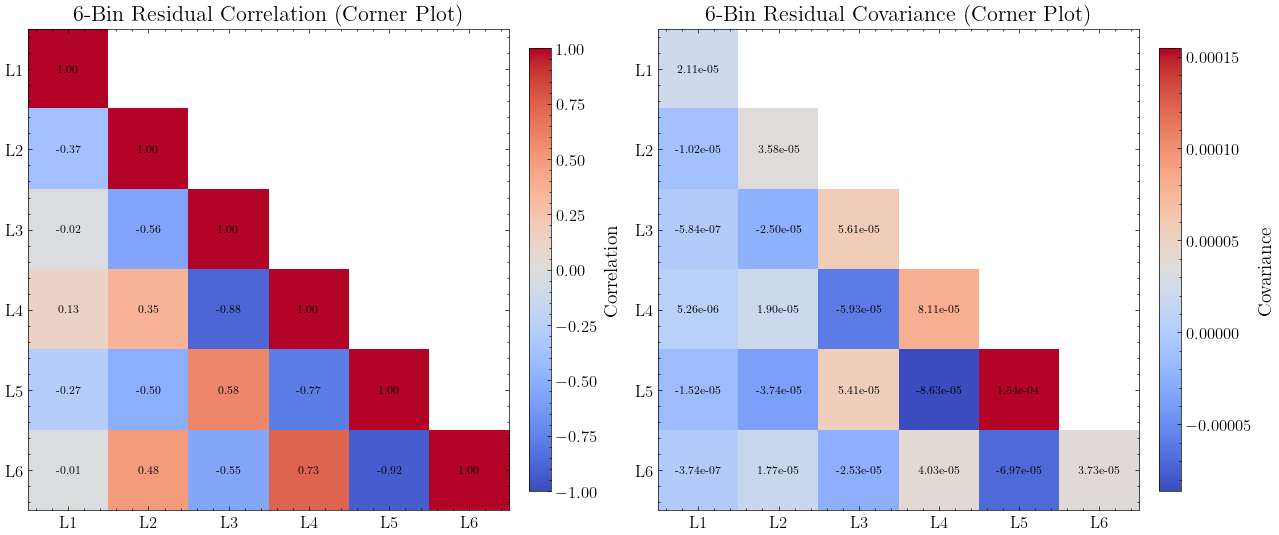

In [102]:
# Correlation + covariance matrices for 6-bin residuals (corner-style)
label_names_6 = [f'L{i+1}' for i in range(6)]

# Residuals for 6-bin model are defined above as: res_lin_6 = lin_pred_6 - lin_true_6
corr_res_6 = np.corrcoef(res_lin_6, rowvar=False)
cov_res_6 = np.cov(res_lin_6, rowvar=False)

corr_df_6 = pd.DataFrame(corr_res_6, index=label_names_6, columns=label_names_6)
cov_df_6 = pd.DataFrame(cov_res_6, index=label_names_6, columns=label_names_6)
# Keep only lower triangle (including diagonal) to avoid duplicate mirrored entries
mask_upper = np.triu(np.ones_like(corr_res_6, dtype=bool), k=1)
corr_corner = np.ma.array(corr_res_6, mask=mask_upper)
cov_corner = np.ma.array(cov_res_6, mask=mask_upper)

fig, ax = plt.subplots(1, 2, figsize=(12.8, 5.6), constrained_layout=True)

im0 = ax[0].imshow(corr_corner, cmap='coolwarm', vmin=-1, vmax=1)
ax[0].set_xticks(range(6))
ax[0].set_yticks(range(6))
ax[0].set_xticklabels(label_names_6)
ax[0].set_yticklabels(label_names_6)
ax[0].set_title('6-Bin Residual Correlation (Corner Plot)')
for i in range(6):
    for j in range(i + 1):
        ax[0].text(j, i, f'{corr_res_6[i, j]:.2f}', ha='center', va='center', fontsize=8)
cbar0 = fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
cbar0.set_label('Correlation')

im1 = ax[1].imshow(cov_corner, cmap='coolwarm')
ax[1].set_xticks(range(6))
ax[1].set_yticks(range(6))
ax[1].set_xticklabels(label_names_6)
ax[1].set_yticklabels(label_names_6)
ax[1].set_title('6-Bin Residual Covariance (Corner Plot)')
for i in range(6):
    for j in range(i + 1):
        ax[1].text(j, i, f'{cov_res_6[i, j]:.2e}', ha='center', va='center', fontsize=8)
cbar1 = fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
cbar1.set_label('Covariance')

plt.show()

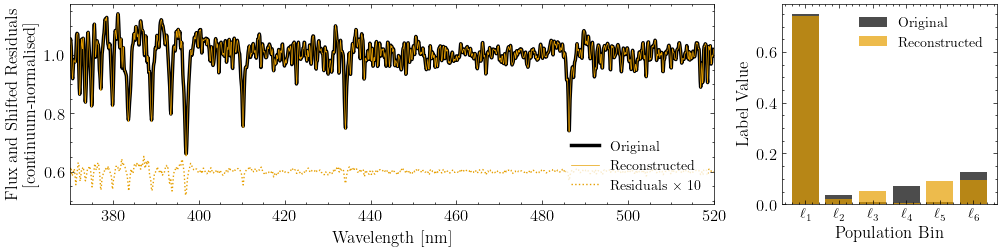

In [118]:
n = 633

fig, ax = plt.subplots(1, 2, figsize=(10,2.5), sharex='col',gridspec_kw={'width_ratios': [3, 1]}, constrained_layout=True)

ax[0].plot(wav/10, lin_true_6[n] @ six_norm_vals, 'k', linewidth=2.5, label='Original')
ax[0].plot(wav/10, lin_pred_6[n] @ six_norm_vals, 'C0', linewidth=0.5, label='Reconstructed')
ax[0].plot(wav/10, (res_lin_6[n] @ six_norm_vals)*10 + 0.6, 'C0:', linewidth=1, label='Residuals $\\times$ 10')
ax[0].set_xlabel('Wavelength [nm]', fontsize=12)
ax[0].set_xlim(370, 520)
ax[0].legend(fontsize=10, loc='lower right', frameon=True, edgecolor='white', facecolor='white', framealpha=0.8)
ax[0].set_ylabel('Flux and Shifted Residuals\n[continuum-normalised]', fontsize=12)

ax[1].bar(range(len(lin_true_6[n])), lin_true_6[n], color='k', alpha=0.7, label='Original')
ax[1].bar(range(len(lin_pred_6[n])), lin_pred_6[n], color='C0', alpha=0.7, label='Reconstructed')
ax[1].legend(fontsize=10)
ax[1].set_xlabel('Population Bin', fontsize=12)
ax[1].set_xticks(range(6))
ax[1].set_xticklabels([f'$\\ell_{{{i}}}$' for i in range(1, 7)], fontsize=10)
ax[1].set_ylabel('Label Value', fontsize=12)

#plt.tight_layout()
plt.savefig('/home/vmehta/honours-project/thesis/figures/conf1spec.pdf', format='pdf')
plt.show()

In [113]:
np.argmax(np.sum(abs(res_lin_6), axis=1))

np.int64(633)

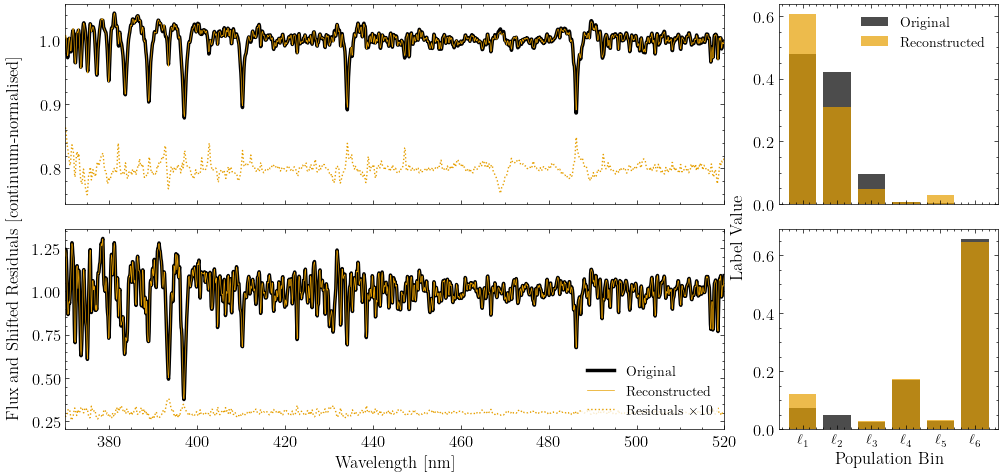

In [ ]:
n = 175
m = 46

fig, ax = plt.subplots(2, 2, figsize=(10,5), sharex='col',gridspec_kw={'width_ratios': [3, 1]})

ax[0,0].plot(wav/10, lin_true_6[n] @ six_norm_vals, 'k', linewidth=2.5, label='Original')
ax[0,0].plot(wav/10, lin_pred_6[n] @ six_norm_vals, 'C0', linewidth=0.5, label='Reconstructed')
ax[0,0].plot(wav/10, (res_lin_6[n] @ six_norm_vals)*10 + 0.8, 'C0:', linewidth=1, label='Residuals')

ax[1,0].plot(wav/10, lin_true_6[m] @ six_norm_vals, 'k', linewidth=2.5, label='Original')
ax[1,0].plot(wav/10, lin_pred_6[m] @ six_norm_vals, 'C0', linewidth=0.5, label='Reconstructed')
ax[1,0].plot(wav/10, (res_lin_6[m] @ six_norm_vals)*10 + 0.3, 'C0:', linewidth=1, label='Residuals $\\times 10$')

ax[1,0].set_xlabel('Wavelength [nm]', fontsize=12)
ax[1,0].set_xlim(370, 520)
ax[1,0].legend(fontsize=10, loc='lower right', frameon=True, facecolor='white', edgecolor='white', framealpha=0.8)

ax[0,1].bar(range(len(lin_true_6[n])), lin_true_6[n], color='k', alpha=0.7, label='Original')
ax[0,1].bar(range(len(lin_pred_6[n])), lin_pred_6[n], color='C0', alpha=0.7, label='Reconstructed')
ax[0,1].legend(fontsize=10)

ax[1,1].bar(range(len(lin_true_6[m])), lin_true_6[m], color='k', alpha=0.7, label='Original')
ax[1,1].bar(range(len(lin_pred_6[m])), lin_pred_6[m], color='C0', alpha=0.7, label='Reconstructed')
ax[1,1].set_xlabel('Population Bin', fontsize=12)
ax[1,1].set_xticks(range(6))
ax[1,1].set_xticklabels([f'$\\ell_{{{i}}}$' for i in range(1, 7)], fontsize=10)
ax[1,1].set_ylabel('', fontsize=12)

fig.text(-0.01, 0.5, 'Flux and Shifted Residuals [continuum-normalised]', va='center', rotation='vertical', fontsize=12)
fig.text(0.715, 0.5, 'Label Value', va='center', rotation='vertical', fontsize=12)

plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/6binspec.pdf', format='pdf')
plt.show()

## 10-label plots

In [90]:
f10 = '/avatar/vmehta/sfh_1000_10bins_20260414_140539/finalmodel/newpriorthing'
pred10 = np.load(f'{f10}/snr1000_all_pred.npy')
true10 = np.load(f'{f10}/snr1000_all_true.npy')
res10 = pred10 - true10
spec10 = np.load('/home/vmehta/honours-project/code/data/sfh_tennormalbins_spectra.npy')

ten_norm_vals = [normalize(v) for v in spec10]

In [91]:
mean_fluxes = np.mean(spec10, axis=1)
total_fluxes = []
for i in range(len(true10)):
    total_flux = np.dot(true10[i], mean_fluxes)
    total_fluxes.append(total_flux)

flux_contributions = np.zeros((1000, 10))
for i in range(1000):
    for j in range(10):
        flux_contributions[i, j] = (true10[i, j] * mean_fluxes[j]) / total_fluxes[i]

In [92]:
mad5lower = np.median(res10) - 5*mad(res10)
mad5upper = np.median(res10) + 5*mad(res10)
mad5lower, mad5upper

(array([-0.00893735, -0.02892135, -0.04523626, -0.04176044, -0.02682232,
        -0.02739456, -0.0974541 , -0.17640465, -0.18911005, -0.09153998]),
 array([0.00893735, 0.02892135, 0.04523626, 0.04176044, 0.02682232,
        0.02739456, 0.0974541 , 0.17640465, 0.18911005, 0.09153998]))

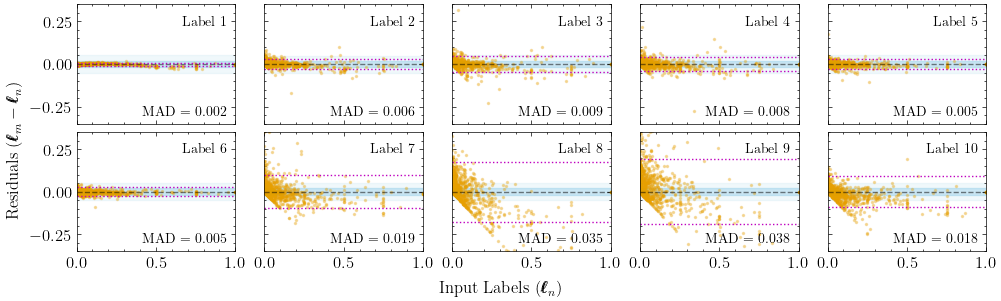

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(10,3), sharex=True, sharey=True, constrained_layout=True)
for i in range(5):
    ax[0, i].plot(true10[:,i], res10[:,i], '.', markersize=3, alpha=0.3)
    ax[1, i].plot(true10[:,5+i], res10[:,5+i], '.', markersize=3, alpha=0.3)
    ax[0, i].plot([0,1], [0,0], 'k--', alpha=0.5)
    ax[1, i].plot([0,1], [0,0], 'k--', alpha=0.5)
    ax[0, i].hlines([mad5lower[i]], [0], [1], 'm', linestyles='dotted')
    ax[1, i].hlines([mad5lower[i+5]], [0], [1], 'm', linestyles='dotted')
    ax[0, i].hlines([mad5upper[i]], [0], [1], 'm', linestyles='dotted')
    ax[1, i].hlines([mad5upper[i+5]], [0], [1], 'm', linestyles='dotted')
    ax[0, i].text(0.95, 0.9, f'Label {i+1}', transform=ax[0, i].transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
    ax[1, i].text(0.95, 0.9, f'Label {i+6}', transform=ax[1, i].transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
    ax[0, i].text(0.95, 0.05, f'MAD = {mad(res10[:,i]):.3f}', transform=ax[0, i].transAxes, fontsize=10, va='bottom', ha='right')
    ax[1, i].text(0.95, 0.05, f'MAD = {mad(res10[:,5+i]):.3f}', transform=ax[1, i].transAxes, fontsize=10, va='bottom', ha='right')

    for bands, color, _, z in band_specs:
        ax[0, i].axhspan(bands[i][0], bands[i][1], color=color, alpha=0.3)
        ax[1, i].axhspan(bands[i][0], bands[i][1], color=color, alpha=0.3)

ax[0,0].set_ylim(-0.35, 0.35)
ax[0,0].set_xlim(0,1)

fig.supxlabel(r'Input Labels $(\pmb\ell_n)$', fontsize=12)
fig.supylabel('Residuals $(\\pmb\\ell_m - \\pmb\\ell_n)$', fontsize=12)

#plt.savefig('/home/vmehta/honours-project/thesis/figures/10binresiduals.pdf', format='pdf')
plt.show()

In [ ]:
# Tolerance statistics for 10-label residuals
# Uses median-centered bands per label, analogous to the 3/6-label stats.
threshold_rows_10 = []

for i in range(10):
    r = res10[:, i]
    center = np.median(r)

    b1_lo, b1_hi = center - 0.01, center + 0.01
    b2_lo, b2_hi = center - 0.02, center + 0.02
    b5_lo, b5_hi = center - 0.05, center + 0.05

    pct_outside_1 = np.mean((r < b1_lo) | (r > b1_hi)) * 100
    pct_outside_2 = np.mean((r < b2_lo) | (r > b2_hi)) * 100
    pct_outside_5 = np.mean((r < b5_lo) | (r > b5_hi)) * 100

    threshold_rows_10.append({
        'label': f'Label {i+1}',
        'median_residual': center,
        'pct_outside_1pct_band': pct_outside_1,
        'pct_outside_2pct_band': pct_outside_2,
        'pct_outside_5pct_band': pct_outside_5,
        'pct_outside_mad5': np.mean(np.abs(r) > 5*mad(r)) * 100
    })

threshold_stats_10 = pd.DataFrame(threshold_rows_10)
threshold_stats_10

,label,median_residual,pct_outside_1pct_band,pct_outside_2pct_band,pct_outside_5pct_band,pct_outside_mad5
0,Label 1,-1.293942e-08,73.1,61.1,41.7,14.5
1,Label 2,0.000000e+00,70.5,56.9,38.3,14.9
2,Label 3,8.945420e-04,25.7,10.3,2.3,8.3
3,Label 4,-3.587086e-07,20.1,4.8,0.7,3.4
4,Label 5,1.659776e-35,23.1,4.4,0.1,3.5
5,Label 6,-2.103583e-05,37.9,13.1,0.6,1.8
6,Label 7,7.428578e-04,25.2,4.9,0.1,2.3
7,Label 8,-1.508454e-04,32.1,10.0,0.5,4.6
8,Label 9,3.353128e-17,49.9,27.2,3.8,3.8
9,Label 10,-3.024348e-04,28.5,6.6,0.8,2.8


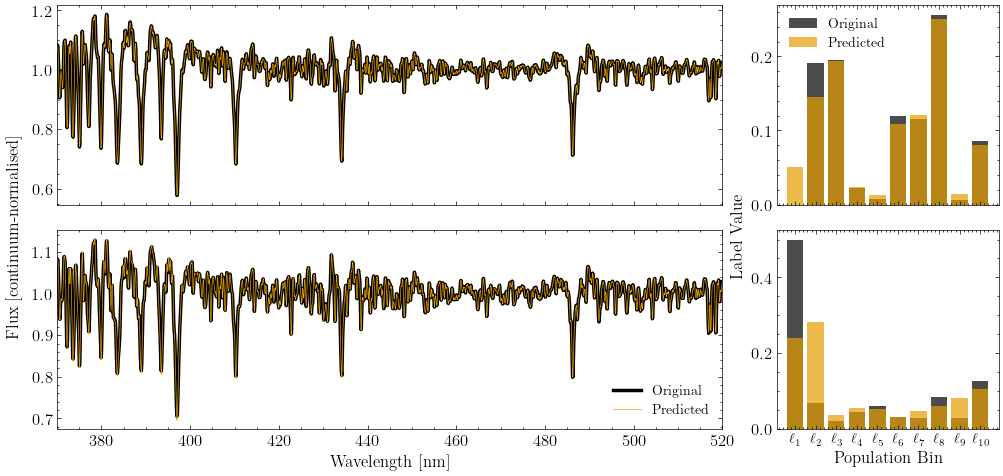

In [ ]:
n = 0
m = 2

fig, ax = plt.subplots(2, 2, figsize=(10,5), sharex='col',gridspec_kw={'width_ratios': [3, 1]})

ax[0,0].plot(wav/10, true10[n] @ ten_norm_vals, 'k', linewidth=2.5, label='Original')
ax[0,0].plot(wav/10, pred10[n] @ ten_norm_vals, 'C0', linewidth=0.5, label='Predicted')

ax[1,0].plot(wav/10, true10[m] @ ten_norm_vals, 'k', linewidth=2.5, label='Original')
ax[1,0].plot(wav/10, pred10[m] @ ten_norm_vals, 'C0', linewidth=0.5, label='Predicted')
ax[1,0].set_xlabel('Wavelength [nm]', fontsize=12)
ax[1,0].set_xlim(370, 520)
ax[1,0].legend(fontsize=10, loc='lower right')

ax[0,1].bar(range(len(true10[n])), true10[n], color='k', alpha=0.7, label='Original')
ax[0,1].bar(range(len(pred10[n])), pred10[n], color='C0', alpha=0.7, label='Predicted')
ax[0,1].legend(fontsize=10)

ax[1,1].bar(range(len(true10[m])), true10[m], color='k', alpha=0.7, label='Original')
ax[1,1].bar(range(len(pred10[m])), pred10[m], color='C0', alpha=0.7, label='Predicted')
ax[1,1].set_xlabel('Population Bin', fontsize=12)
ax[1,1].set_xticks(range(10))
ax[1,1].set_xticklabels([f'$\\ell_1$', f'$\\ell_2$', f'$\\ell_3$', f'$\\ell_4$', f'$\\ell_5$', f'$\\ell_6$', f'$\\ell_7$', f'$\\ell_8$', f'$\\ell_9$', f'$\\ell_{{10}}$'], fontsize=10)
ax[1,1].set_ylabel('', fontsize=12)

fig.text(-0.01, 0.5, 'Flux [continuum-normalised]', va='center', rotation='vertical', fontsize=12)
fig.text(0.715, 0.5, 'Label Value', va='center', rotation='vertical', fontsize=12)

plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/10binmodel_example.pdf', format='pdf')
plt.show()

10-label residual correlation matrix:


,L1,L2,L3,L4,L5,L6,L7,L8,L9,L10
L1,1.000000,-0.976997,0.299874,-0.393211,0.395001,-0.335074,-0.046441,-0.089415,-0.306961,0.014174
L2,-0.976997,1.000000,-0.492312,0.313350,-0.368362,0.319380,0.032737,0.086365,0.289582,-0.035262
L3,0.299874,-0.492312,1.000000,0.046481,0.034289,-0.074785,0.047688,-0.008982,0.005184,0.031208
L4,-0.393211,0.313350,0.046481,1.000000,-0.315033,0.299569,-0.081031,0.040650,-0.180789,0.371770
L5,0.395001,-0.368362,0.034289,-0.315033,1.000000,-0.903470,0.279591,-0.053637,-0.027156,-0.066889
L6,-0.335074,0.319380,-0.074785,0.299569,-0.903470,1.000000,-0.552846,0.305764,-0.250806,0.313254
L7,-0.046441,0.032737,0.047688,-0.081031,0.279591,-0.552846,1.000000,-0.866523,0.619505,-0.491793
L8,-0.089415,0.086365,-0.008982,0.040650,-0.053637,0.305764,-0.866523,1.000000,-0.682054,0.617920
L9,-0.306961,0.289582,0.005184,-0.180789,-0.027156,-0.250806,0.619505,-0.682054,1.000000,-0.917071
L10,0.014174,-0.035262,0.031208,0.371770,-0.066889,0.313254,-0.491793,0.617920,-0.917071,1.000000


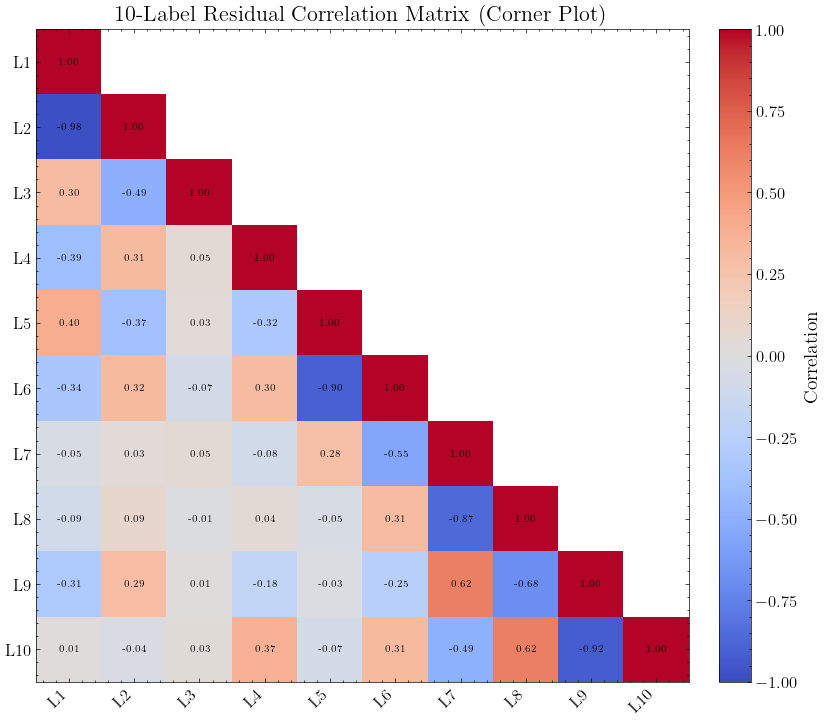

In [ ]:
# Correlation matrix for 10-label residuals (corner-style)
label_names_10 = [f'L{i+1}' for i in range(10)]

# Residuals for 10-label model are defined above as: res10 = pred10 - true10
corr_res_10 = np.corrcoef(res10, rowvar=False)

corr_df_10 = pd.DataFrame(corr_res_10, index=label_names_10, columns=label_names_10)

# Keep only lower triangle (including diagonal) to avoid duplicate mirrored entries
mask_upper = np.triu(np.ones_like(corr_res_10, dtype=bool), k=1)
corr_corner_10 = np.ma.array(corr_res_10, mask=mask_upper)

fig, ax = plt.subplots(1, 1, figsize=(8.8, 7.2), constrained_layout=True)
im = ax.imshow(corr_corner_10, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(label_names_10, rotation=45, ha='right')
ax.set_yticklabels(label_names_10)
ax.set_title('10-Label Residual Correlation Matrix (Corner Plot)')

for i in range(10):
    for j in range(i + 1):
        ax.text(j, i, f'{corr_res_10[i, j]:.2f}', ha='center', va='center', fontsize=7)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation')

plt.show()

In [1]:
import matplotlib.pyplot as plt
from utils import *
plt.style.use('thesis')
import numpy as np
import pandas as pd

In [25]:
binning_schemes = {}
files = {'f4': 'sfh_1000_4bins_20260421_112531', 'f6': 'sfh_1000_6bins_20260421_112745', 'f8': 'sfh_1000_8bins_20260419_102022', 'f10': 'sfh_1000_10bins_20260421_105603'}
snrs = ['snr1000', 'snr500', 'snr100', 'snr50', 'snr10']

for key, fname in files.items():
    binning_schemes[key] = {}
    for snr in snrs:
        base = f'/avatar/vmehta/{fname}/finalmodel/'
        pred = np.load(f'{base}/{snr}_all_pred.npy')
        true = np.load(f'{base}/{snr}_all_true.npy')
        res = true - pred
        res_rmse = rmse(true, pred)
        res_mae = mae(true, pred)
        binning_schemes[key][snr] = {
            'rmse': res_rmse,
            'mae': res_mae
        }
    bin_arr = np.log10(np.r_[np.array([0.1])*1e6, np.logspace(7, 10.15, int(key[1:]))])
    centers = [(bin_arr[i]+bin_arr[i+1])/2 for i in range(len(bin_arr)-1)]
    x_lower = centers - bin_arr[:-1]
    x_upper = bin_arr[1:] - centers
    binning_schemes[key]['centers'] = centers
    binning_schemes[key]['x_lower'] = x_lower
    binning_schemes[key]['x_upper'] = x_upper

In [26]:
type(bin_arr)

numpy.ndarray

In [52]:
schemes = ['Log-uniform', 'Conf1', 'Conf2', 'Conf3']
binarr_loguniform = np.log10(np.logspace(5, 10.15, 7))
binarr_conf1 = np.r_[np.array([0.1, 20, 100, 500, 1000, 3000])*1e6, np.array([10**10.15])]
binarr_conf2 = np.r_[np.array([0.1, 10, 50, 100, 1000, 2500])*1e6, np.array([10**10.15])]
binarr_conf3 = np.r_[np.array([0.1])*1e6, np.logspace(7, 10.15, 6)]



bin_arr = np.array([binarr_loguniform, binarr_conf1, binarr_conf2, binarr_conf3])
centers = [(bin_arr[i]+bin_arr[i+1])/2 for i in range(len(bin_arr)-1)]
x_lower = centers - bin_arr[:-1]
x_upper = bin_arr[1:] - centers

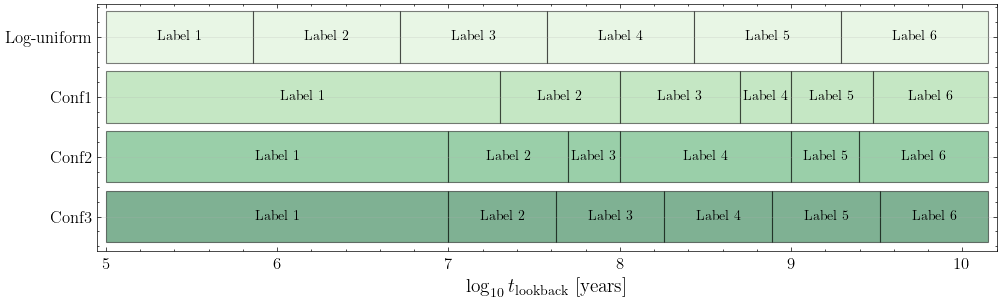

In [64]:
# Plot the four six-bin configurations defined above, using log10 lookback time on the x-axis.
fig, ax = plt.subplots(1, 1, figsize=(10, 3), constrained_layout=True)

row_step = 0.72
bar_h = 0.62
colors = [plt.cm.Greens(v) for v in np.linspace(0.2, 0.9, len(schemes))]


def to_log10_edges(edges):
    edges = np.asarray(edges, dtype=float)
    if np.nanmax(edges) <= 20:
        return edges
    return np.log10(edges)


for row_idx, (scheme, edges, color) in enumerate(zip(schemes, bin_arr, colors), start=1):
    y = 4-row_idx * row_step
    log_edges = to_log10_edges(edges)
    centers = 0.5 * (log_edges[:-1] + log_edges[1:])

    for bin_idx in range(len(centers)):
        left = log_edges[bin_idx]
        width = log_edges[bin_idx+1] - log_edges[bin_idx]
        ax.barh(
            y,
            width,
            left=left,
            height=bar_h,
            color=color,
            edgecolor='k',
            linewidth=0.8,
            alpha=0.5,
        )
        ax.text(
            centers[bin_idx],
            y,
            f'Label {bin_idx + 1}',
            ha='center',
            va='center',
            fontsize=10,
            color='k',
        )

ax.set_xlim(4.95, 10.2)
ax.set_ylim(0.7, row_step * (len(schemes) + 1.1))
ax.set_yticks([4 - i * row_step for i in range(1, len(schemes) + 1)])
ax.set_yticklabels(schemes)
ax.set_xlabel(r'$\log_{10} t_{\mathrm{lookback}}$ [years]')
ax.grid(axis='y', alpha=0.3)

plt.savefig('/home/vmehta/honours-project/thesis/figures/6label_binning_schemes.pdf', format='pdf')
plt.show()


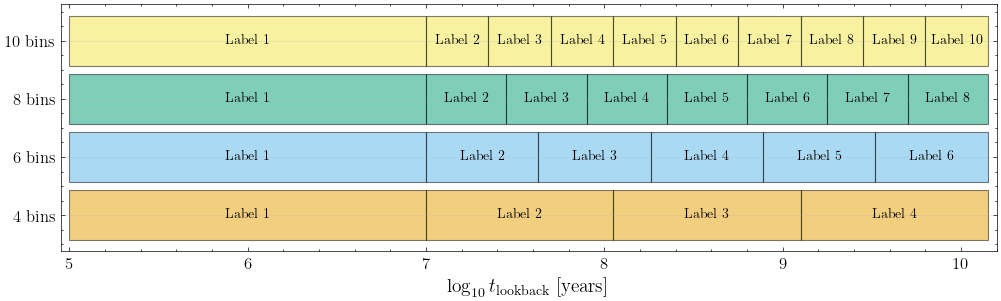

In [39]:
# Reconstruct the binning schemes from centers and x-errors, then plot as filled horizontal bins
fig, ax = plt.subplots(1, 1, figsize=(10, 3), constrained_layout=True)

scheme_keys = sorted(binning_schemes.keys(), key=lambda k: int(k[1:]))
# Use thesis style default color cycle instead of viridis
colors = [f'C{i}' for i in range(len(scheme_keys))]

# Tighter vertical packing between rows
row_step = 0.72
bar_h = 0.62

for row_idx, (key, color) in enumerate(zip(scheme_keys, colors), start=1):
    y = row_idx * row_step
    centers = np.asarray(binning_schemes[key]['centers'])
    x_lower = np.asarray(binning_schemes[key]['x_lower'])
    x_upper = np.asarray(binning_schemes[key]['x_upper'])

    left_edge = centers[0] - x_lower[0]
    right_edges = centers + x_upper
    edges = np.r_[left_edge, right_edges]

    for i in range(len(centers)):
        width = edges[i + 1] - edges[i]
        ax.barh(
            y, width, left=edges[i], height=bar_h,
            color=color, edgecolor='k', linewidth=0.8, alpha=0.5
        )
        ax.text(
            centers[i], y, f'Label {i+1}',
            ha='center', va='center', fontsize=10, color='k'
        )

y_positions = [i * row_step for i in range(1, len(scheme_keys) + 1)]
ax.set_xlim(4.95, 10.2)
ax.set_yticks(y_positions)
ax.set_yticklabels([f"{int(k[1:])} bins" for k in scheme_keys])
ax.set_xlabel(f'$\\log_{{10}}t_\\mathrm{{lookback}}$ [years]')
ax.grid(axis='y', alpha=0.3)
plt.show()


In [ ]:

# Overall RMSE comparisons
snr_labels = ['snr1000', 'snr500', 'snr100', 'snr50', 'snr10']
snr_values = np.array([int(s.replace('snr', '')) for s in snr_labels])
n_labels = np.array([int(k[1:]) for k in scheme_keys])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2), constrained_layout=True, sharey=True)

# Left: overall RMSE vs SNR, one line per binning scheme
for key, color in zip(scheme_keys, colors):
    nbin = int(key[1:])
    overall_rmse = [binning_schemes[key][snr]['rmse'][1] for snr in snr_labels]
    ax[1].plot(
        snr_values, overall_rmse, '-o', color=color, label=f'{nbin} bins'
    )

# Right: overall RMSE vs number of labels, one line per SNR
snr_line_colors = [plt.cm.Blues(v) for v in np.linspace(0.35, 0.9, 5)]
for snr, color in zip(snr_labels, snr_line_colors):
    rmse_vs_labels = [binning_schemes[key][snr]['rmse'][1] for key in scheme_keys]
    ax[0].plot(
        n_labels, rmse_vs_labels, '-o', color=color,
        label=snr[3:]  # Remove 'snr' prefix
    )


ax[1].set_xlabel('SNR')
ax[1].grid(alpha=0.25)
ax[1].axhline(0.05, color='k', linestyle='--')

ax[0].set_xlabel('Number of Labels')
ax[0].set_xticks(n_labels)
ax[0].grid(alpha=0.25)
ax[0].axhline(0.05, color='k', linestyle='--')

ax[1].legend(title='Model', fontsize=10, loc='upper right')
ax[0].legend(title='SNR', fontsize=10, ncol=2, loc='upper left')
ax[0].set_ylabel('$\\Delta\\pmb\\ell_\\mathrm{RMSE}$')

#plt.savefig('/home/vmehta/honours-project/thesis/figures/labels_rmse.pdf', format='pdf')
plt.show()

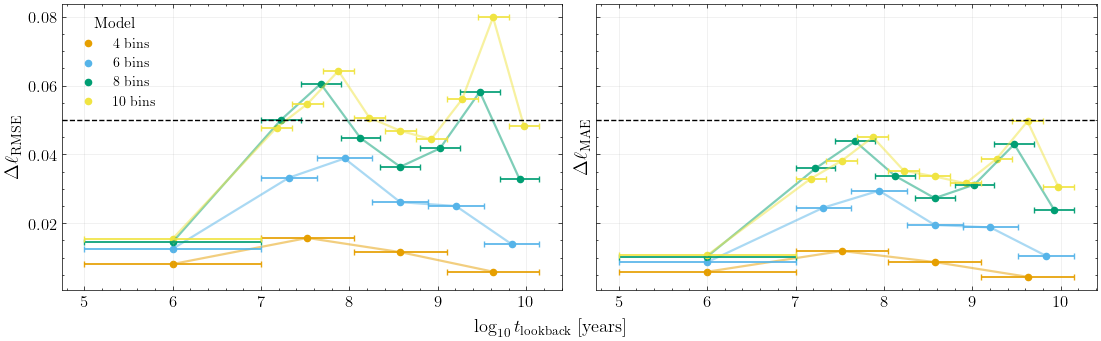

In [8]:
# Per-label RMSE and MAE for SNR=100, plotted against bin centers
snr_target = 'snr100'

# Use thesis/default style cycle explicitly for consistency
scheme_keys = sorted(binning_schemes.keys(), key=lambda k: int(k[1:]))
style_colors = [f'C{i}' for i in range(len(scheme_keys))]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharex=False, constrained_layout=True, sharey=True)

for key, color in zip(scheme_keys, style_colors):
    nbin = int(key[1:])
    centers = np.asarray(binning_schemes[key]['centers'])
    x_lower = np.asarray(binning_schemes[key]['x_lower'])
    x_upper = np.asarray(binning_schemes[key]['x_upper'])
    xerr = np.vstack([x_lower, x_upper])

    rmse_per_label = np.asarray(binning_schemes[key][snr_target]['rmse'][0])
    mae_per_label = np.asarray(binning_schemes[key][snr_target]['mae'][0])

    # Draw faint connecting line only
    ax[0].plot(centers, rmse_per_label, '-', color=color, linewidth=1.6, alpha=0.5)
    ax[1].plot(centers, mae_per_label, '-', color=color, linewidth=1.6, alpha=0.5)

    # Draw opaque error bars (no markers/line)
    ax[0].errorbar(
        centers, rmse_per_label, xerr=xerr, fmt='none', ecolor=color,
        elinewidth=1.3, capsize=2, alpha=0.95
    )
    ax[1].errorbar(
        centers, mae_per_label, xerr=xerr, fmt='none', ecolor=color,
        elinewidth=1.3, capsize=2, alpha=0.95
    )

    # Draw opaque points
    ax[0].scatter(centers, rmse_per_label, s=20, color=color, label=f'{nbin} bins')
    ax[1].scatter(centers, mae_per_label, s=20, color=color)

ax[0].axhline(0.05, color='k', linestyle='--')
ax[1].axhline(0.05, color='k', linestyle='--')
ax[0].set_ylabel('$\\Delta\\ell_\\mathrm{RMSE}$')
ax[1].set_ylabel('$\\Delta\\ell_\\mathrm{MAE}$')
fig.supxlabel(f'$\\log_{{10}}t_\\mathrm{{lookback}}$ [years]')
ax[0].grid(alpha=0.25)
ax[1].grid(alpha=0.25)

ax[0].legend(title='Model', fontsize=10, loc='upper left')

plt.savefig('/home/vmehta/honours-project/thesis/figures/perlabel100.pdf', format='pdf')
plt.show()

In [9]:
binning_schemes

{'f4': {'snr1000': {'rmse': (array([0.00422651, 0.00452588, 0.00274726, 0.00302315]),
    np.float64(0.0037092394642044696)),
   'mae': (array([0.00290539, 0.00333919, 0.0020107 , 0.00211422]),
    0.002592375155976777)},
  'snr500': {'rmse': (array([0.00556258, 0.0066812 , 0.00394834, 0.00413142]),
    np.float64(0.005201890479021868)),
   'mae': (array([0.0038399 , 0.00501866, 0.00292452, 0.00290488]),
    0.0036719929738900908)},
  'snr100': {'rmse': (array([0.00811242, 0.01569953, 0.01157522, 0.0058853 ]),
    np.float64(0.010964818433037496)),
   'mae': (array([0.00586896, 0.01190468, 0.00868257, 0.00439581]),
    0.007713005444044809)},
  'snr50': {'rmse': (array([0.01230371, 0.02968619, 0.02321884, 0.00866294]),
    np.float64(0.020290465067648054)),
   'mae': (array([0.00945836, 0.02239744, 0.0176955 , 0.006753  ]),
    0.014076073440384248)},
  'snr10': {'rmse': (array([0.05373546, 0.12654228, 0.09666163, 0.03784906]),
    np.float64(0.086134299546886)),
   'mae': (array([0.04

In [10]:
# Create array of average RMSE for each bin/SNR combination
scheme_keys = sorted(binning_schemes.keys(), key=lambda k: int(k[1:]))
snr_keys = ['snr1000', 'snr500', 'snr100', 'snr50', 'snr10']

# Create 2D array: rows=bin schemes, cols=SNRs
avg_rmse_array = np.zeros((len(scheme_keys), len(snr_keys)))

for i, scheme_key in enumerate(scheme_keys):
    for j, snr_key in enumerate(snr_keys):
        avg_rmse_array[i, j] = binning_schemes[scheme_key][snr_key]['rmse'][1]

# Create a labeled DataFrame for easier viewing
avg_rmse_df = pd.DataFrame(
    avg_rmse_array,
    index=[f"{int(k[1:])} bins" for k in scheme_keys],
    columns=snr_keys
)

print("Average RMSE by bin scheme and SNR:")
print(avg_rmse_df)
print("\nArray shape:", avg_rmse_array.shape)

Average RMSE by bin scheme and SNR:
          snr1000    snr500    snr100     snr50     snr10
4 bins   0.003709  0.005202  0.010965  0.020290  0.086134
6 bins   0.006551  0.009555  0.026665  0.045804  0.112635
8 bins   0.013509  0.017569  0.044598  0.064565  0.132579
10 bins  0.019849  0.025000  0.053132  0.079686  0.145622

Array shape: (4, 5)


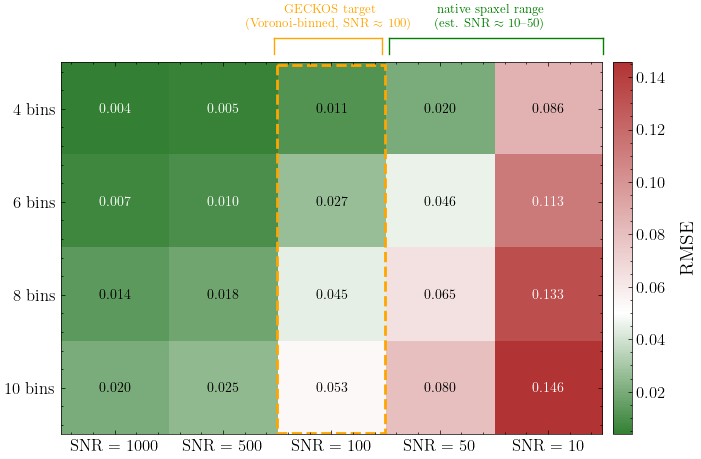

In [ ]:
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

# Redefine scheme_keys and snr_keys explicitly
scheme_keys = sorted(['f4', 'f6', 'f8', 'f10'], key=lambda k: int(k[1:]))
snr_keys = ['snr1000', 'snr500', 'snr100', 'snr50', 'snr10']

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

# Calculate where 0.05 falls in the data range (normalized to [0, 1])
vmin = avg_rmse_array.min()
vmax = avg_rmse_array.max()
white_position = (0.05 - vmin) / (vmax - vmin)

# Create a custom colormap with muted colors: forest green -> white -> wine red
cdict = {
    'red':   [(0.0, 0.2, 0.2),      # Muted green (low red)
              (white_position, 1.0, 1.0),  # White at 0.05 position
              (1.0, 0.7, 0.7)],     # Muted red
    'green': [(0.0, 0.5, 0.5),      # Muted green
              (white_position, 1.0, 1.0),  # White at 0.05 position
              (1.0, 0.2, 0.2)],     # Muted red (low green)
    'blue':  [(0.0, 0.2, 0.2),      # Muted green (low blue)
              (white_position, 1.0, 1.0),  # White at 0.05 position
              (1.0, 0.2, 0.2)]      # Muted red (low blue)
}
cmap = LinearSegmentedColormap('green_white_red', cdict, N=256)

# Use linear normalization
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# Create the heatmap
im = ax.imshow(avg_rmse_array, aspect='auto', cmap=cmap, norm=norm)

# Set ticks and labels
ax.set_xticks(range(len(snr_keys)))
ax.set_yticks(range(len(scheme_keys)))
ax.set_xticklabels([f"SNR = {k.replace('snr', '')}" for k in snr_keys])
ax.set_yticklabels([f"{int(k[1:])} bins" for k in scheme_keys])

# Add colorbar with adjusted spacing
cbar = fig.colorbar(im, ax=ax, fraction=0.1, pad=0.02)
cbar.set_label('RMSE', labelpad=10)

# Add text annotations with values (white text for dark backgrounds, black for light)
for i in range(len(scheme_keys)):
    for j in range(len(snr_keys)):
        value = avg_rmse_array[i, j]
        # Use white text if value is far from white point (0.05), black if near it
        text_color = "white" if abs(value - 0.05) > 0.04 else "black"
        ax.text(j, i, f'{value:.3f}',
                ha="center", va="center", color=text_color, fontsize=10, fontweight='bold')

# Add dashed boxes for GECKOS target (SNR = 100, column index 2)
rect_geckos = Rectangle((1.5, -0.47), 1, 3.95, 
                         linewidth=2, edgecolor='orange', facecolor='none', 
                         linestyle='--')
ax.add_patch(rect_geckos)

# Add text annotations in whitespace above axes using figure coordinates
fig.text(0.47, 1.07, 'GECKOS target\n(Voronoi-binned, SNR $\\approx$ 100)',
         ha='center', va='bottom', color='orange', fontsize=9, fontweight='bold')

fig.text(0.7, 1.07, 'native spaxel range\n(est. SNR $\\approx$ 10--50)',
         ha='center', va='bottom', color='green', fontsize=9, fontweight='bold')

# Draw brackets in figure coordinates (whitespace above axes)
from matplotlib.lines import Line2D

# Bracket positions in figure coordinates (normalized 0-1)
# Position brackets just below the text in figure space
bracket_y_top = 1.01  # Top of bracket (at the text)
bracket_y_bottom = 1.05  # Bottom of bracket (opening downward)

# GECKOS bracket (orange)
geckos_x_left = 0.39
geckos_x_right = 0.545

# Left vertical line
line1 = Line2D([geckos_x_left, geckos_x_left], [bracket_y_top, bracket_y_bottom], 
               transform=fig.transFigure, color='orange', linewidth=1)
# Horizontal line
line2 = Line2D([geckos_x_left, geckos_x_right], [bracket_y_bottom, bracket_y_bottom], 
               transform=fig.transFigure, color='orange', linewidth=1)
# Right vertical line
line3 = Line2D([geckos_x_right, geckos_x_right], [bracket_y_bottom, bracket_y_top], 
               transform=fig.transFigure, color='orange', linewidth=1)
fig.add_artist(line1)
fig.add_artist(line2)
fig.add_artist(line3)

# Native spaxel bracket (green)
native_x_left = 0.555
native_x_right = 0.86

# Left vertical line
line4 = Line2D([native_x_left, native_x_left], [bracket_y_top, bracket_y_bottom], 
               transform=fig.transFigure, color='green', linewidth=1)
# Horizontal line
line5 = Line2D([native_x_left, native_x_right], [bracket_y_bottom, bracket_y_bottom], 
               transform=fig.transFigure, color='green', linewidth=1)
# Right vertical line
line6 = Line2D([native_x_right, native_x_right], [bracket_y_bottom, bracket_y_top], 
               transform=fig.transFigure, color='green', linewidth=1)
fig.add_artist(line4)
fig.add_artist(line5)
fig.add_artist(line6)

plt.savefig('/home/vmehta/honours-project/thesis/figures/rmse_heatmap.pdf', format='pdf')
plt.show()